In [1]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['used-cars-price-prediction']


In [2]:
train= pd.read_csv('../input/used-cars-price-prediction/train-data.csv')
train.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


# Visualization

Text(0.5, 1.0, 'Distributional of price')

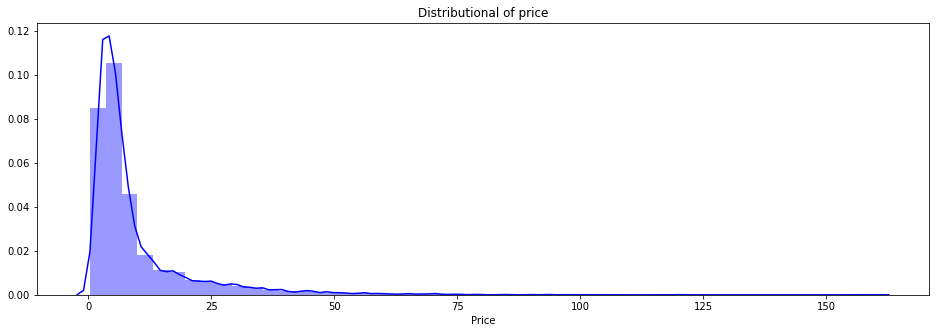

In [3]:
f, axes = plt.subplots(1,1, figsize = (16, 5))
g1 = sns.distplot(train["Price"], color="blue",ax = axes)
plt.title("Distributional of price")

In [4]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

ep = train['Owner_Type'].value_counts().reset_index()
ep.columns = [
    'Owner_Type', 
    'percent'
]
ep['percent'] /= len(train)

fig = px.pie(
    ep, 
    names='Owner_Type', 
    values='percent', 
    title='Countplot of Owner_Type', 
    width=800,
    height=500 
)

fig.show()

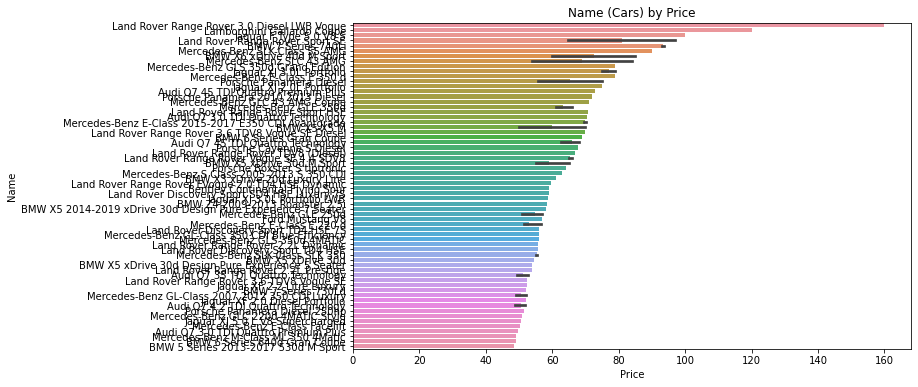

In [5]:
cdi = train.sort_values(by='Price', ascending=False)[:100]
figure = plt.figure(figsize=(10,6))
sns.barplot(y=cdi.Name, x=cdi.Price)
plt.xticks()
plt.xlabel('Price')
plt.ylabel('Name')
plt.title('Name (Cars) by Price')
plt.show()

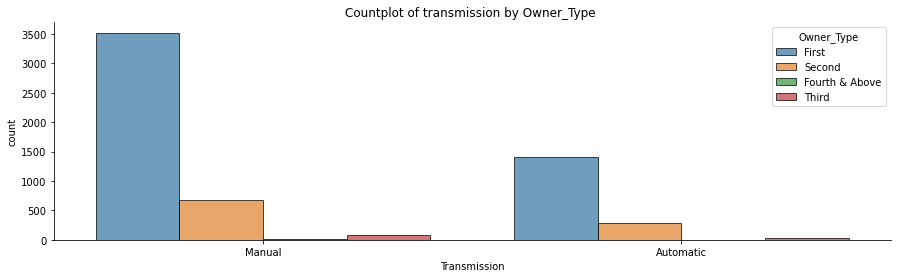

In [6]:

plt.figure(figsize=[15,4])
sns.countplot(x='Transmission', hue='Owner_Type',edgecolor="black", alpha=0.7, data=train)
sns.despine()
plt.title("Countplot of transmission by Owner_Type ")
plt.show()

Text(0.5, 1.0, 'Transmission: Kilometers_Driven comparsion')

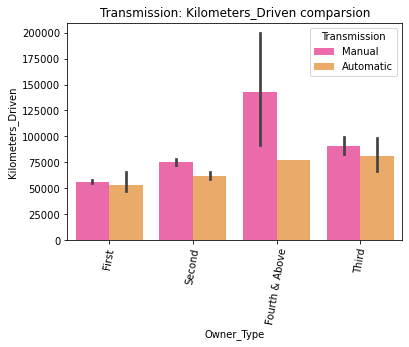

In [7]:
sns.barplot(train["Owner_Type"],train["Kilometers_Driven"],hue= train["Transmission"],palette="spring")
plt.xticks(rotation=80)
plt.title("Transmission: Kilometers_Driven comparsion")

Text(0.5, 1.0, 'Location: Kilometers_Driven comparsion')

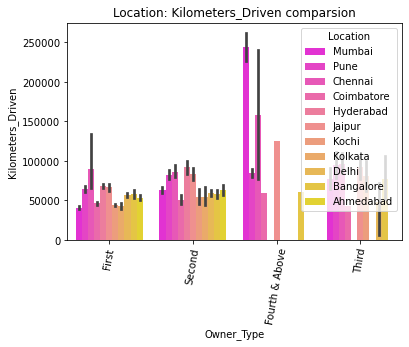

In [8]:
sns.barplot(train["Owner_Type"],train["Kilometers_Driven"],hue= train["Location"],palette="spring")
plt.xticks(rotation=80)
plt.title("Location: Kilometers_Driven comparsion")

# Owner_Type = First

In [9]:
display(train[train["Owner_Type"]=="First"][["Name","Location","Transmission","Year","Kilometers_Driven","Fuel_Type","Mileage","Engine","Power",
                                       "Price"]].sort_values(by="Price", ascending= False).head(10).style.background_gradient(cmap="spring"))

,Name,Location,Transmission,Year,Kilometers_Driven,Fuel_Type,Mileage,Engine,Power,Price
4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Hyderabad,Automatic,2017,25000,Diesel,13.33 kmpl,2993 CC,255 bhp,160.000000
5919,Jaguar F Type 5.0 V8 S,Hyderabad,Automatic,2015,8000,Petrol,12.5 kmpl,5000 CC,488.1 bhp,100.000000
1505,Land Rover Range Rover Sport SE,Kochi,Automatic,2019,26013,Diesel,12.65 kmpl,2993 CC,255 bhp,97.070000
1974,BMW 7 Series 740Li,Coimbatore,Automatic,2018,28060,Petrol,12.05 kmpl,2979 CC,320 bhp,93.670000
1984,BMW 7 Series 740Li,Bangalore,Automatic,2017,17465,Petrol,12.05 kmpl,2979 CC,320 bhp,93.000000
5535,BMW X6 xDrive 40d M Sport,Ahmedabad,Automatic,2015,97003,Diesel,15.87 kmpl,2993 CC,308.43 bhp,85.000000
2095,Mercedes-Benz SLC 43 AMG,Coimbatore,Automatic,2019,2526,Petrol,19.0 kmpl,2996 CC,362.07 bhp,83.960000
1885,Mercedes-Benz GLS 350d Grand Edition,Delhi,Automatic,2018,6000,Diesel,11.0 kmpl,2987 CC,258 bhp,79.000000
2422,Jaguar XJ 3.0L Portfolio,Delhi,Automatic,2016,12000,Diesel,10.5 kmpl,2993 CC,271.23 bhp,79.000000
2319,Mercedes-Benz E-Class E 350 d,Coimbatore,Automatic,2019,9312,Diesel,18.0 kmpl,2987 CC,258 bhp,78.800000


# Owner_Type = Second

In [10]:
display(train[train["Owner_Type"]=="Second"][["Name","Location","Transmission","Year","Kilometers_Driven","Fuel_Type","Mileage","Engine","Power",
                                       "Price"]].sort_values(by="Price", ascending= False).head(10).style.background_gradient(cmap="spring"))

,Name,Location,Transmission,Year,Kilometers_Driven,Fuel_Type,Mileage,Engine,Power,Price
4691,Mercedes-Benz SLK-Class 55 AMG,Bangalore,Automatic,2014,3000,Petrol,12.0 kmpl,5461 CC,421 bhp,90.000000
3489,Porsche Panamera Diesel,Bangalore,Automatic,2013,19828,Diesel,17.85 kmpl,2967 CC,300 bhp,75.000000
5416,Land Rover Range Rover Vogue SE 4.4 SDV8,Coimbatore,Automatic,2013,75995,Diesel,11.49 kmpl,4367 CC,335.3 bhp,65.810000
3242,Land Rover Range Rover Vogue SE 4.4 SDV8,Bangalore,Automatic,2012,63000,Diesel,11.49 kmpl,4367 CC,335.3 bhp,65.000000
5545,Land Rover Range Rover Sport SE,Delhi,Automatic,2014,47000,Diesel,12.65 kmpl,2993 CC,255 bhp,64.750000
5740,BMW X5 xDrive 30d M Sport,Chennai,Automatic,2017,21000,Diesel,15.97 kmpl,2993 CC,258 bhp,55.000000
2537,Audi Q7 35 TDI Quattro Technology,Coimbatore,Automatic,2016,28733,Diesel,12.07 kmpl,2967 CC,241.4 bhp,53.110000
2593,Audi Q7 35 TDI Quattro Technology,Bangalore,Automatic,2015,21000,Diesel,12.07 kmpl,2967 CC,241.4 bhp,52.500000
2896,Porsche Panamera Diesel,Delhi,Automatic,2013,48000,Diesel,17.85 kmpl,2967 CC,300 bhp,50.500000
5302,Audi Q7 3.0 TDI Quattro Premium Plus,Coimbatore,Automatic,2016,31075,Diesel,12.07 kmpl,2967 CC,241.4 bhp,49.790000


# Owner_Type = Third

In [11]:
display(train[train["Owner_Type"]=="Third"][["Name","Location","Transmission","Year","Kilometers_Driven","Fuel_Type","Mileage","Engine","Power",
                                       "Price"]].sort_values(by="Price", ascending= False).head(10).style.background_gradient(cmap="spring"))

,Name,Location,Transmission,Year,Kilometers_Driven,Fuel_Type,Mileage,Engine,Power,Price
5781,Lamborghini Gallardo Coupe,Delhi,Automatic,2011,6500,Petrol,6.4 kmpl,5204 CC,560 bhp,120.000000
2978,Porsche Panamera 2010 2013 4S,Coimbatore,Automatic,2010,42400,Petrol,8.0 kmpl,4806 CC,394.3 bhp,42.910000
2288,Audi A6 3.0 TDI quattro,Bangalore,Automatic,2011,50000,Diesel,16.77 kmpl,2967 CC,241.38 bhp,21.000000
3955,Toyota Fortuner 3.0 Diesel,Bangalore,Manual,2012,100000,Diesel,11.5 kmpl,2982 CC,171 bhp,16.000000
3030,BMW 3 Series 320d Sport,Mumbai,Automatic,2012,37000,Diesel,22.69 kmpl,1995 CC,190 bhp,15.000000
4577,BMW 5 Series 520d Sedan,Delhi,Automatic,2012,72000,Diesel,18.48 kmpl,nan,nan,13.850000
373,Audi Q7 3.0 TDI Quattro Premium Plus,Mumbai,Automatic,2008,99000,Diesel,12.07 kmpl,2967 CC,241.4 bhp,12.950000
5404,BMW 5 Series 2003-2012 520d,Pune,Automatic,2010,170000,Diesel,18.48 kmpl,1995 CC,177 bhp,12.000000
5348,BMW X1 sDrive 20d Exclusive,Chennai,Automatic,2012,115000,Diesel,15.06 kmpl,1995 CC,177 bhp,10.000000
4650,BMW X1 sDrive20d,Chennai,Automatic,2012,85000,Diesel,17.05 kmpl,1995 CC,184 bhp,10.000000


# Owner_Type =Fourth & Above

In [12]:
display(train[train["Owner_Type"]=="Fourth & Above"][["Name","Location","Transmission","Year","Kilometers_Driven","Fuel_Type","Mileage","Engine","Power",
                                       "Price"]].sort_values(by="Price", ascending= False).head(10).style.background_gradient(cmap="spring"))

,Name,Location,Transmission,Year,Kilometers_Driven,Fuel_Type,Mileage,Engine,Power,Price
885,Maruti Grand Vitara AT,Chennai,Automatic,2008,77000,Petrol,9.7 kmpl,1995 CC,163.5 bhp,5.500000
2988,Toyota Innova 2.5 G4 Diesel 8-seater,Chennai,Manual,2005,240000,Diesel,12.8 kmpl,2494 CC,102 bhp,5.100000
29,Toyota Innova 2.5 V Diesel 7-seater,Mumbai,Manual,2007,262000,Diesel,12.8 kmpl,2494 CC,102 bhp,4.000000
1081,Hyundai i20 1.2 Sportz Option,Bangalore,Manual,2010,61000,Petrol,17.0 kmpl,1197 CC,80 bhp,3.250000
1699,Ford Endeavour 4x2 XLT Limited Edition,Pune,Manual,2007,90000,Diesel,10.9 kmpl,2499 CC,143 bhp,3.000000
3404,Maruti Swift 1.3 VXi,Jaipur,Manual,2006,125000,Petrol,16.1 kmpl,nan,nan,2.350000
5647,Toyota Qualis Fleet A3,Mumbai,Manual,2001,227000,Diesel,0.0 kmpl,2446 CC,null bhp,2.200000
3368,Maruti Swift Ldi BSIII,Pune,Manual,2009,80000,Diesel,17.8 kmpl,1248 CC,75 bhp,2.150000
4148,Ford Ikon 1.3 Flair,Coimbatore,Manual,2008,59833,Petrol,13.8 kmpl,1299 CC,70 bhp,1.970000


# Transmission : Automatic


In [13]:
display(train[train["Transmission"]=="Automatic"][["Name","Location","Transmission","Year","Kilometers_Driven","Fuel_Type","Mileage","Engine","Power",
                                       "Price"]].sort_values(by="Price", ascending= False).head(30).style.background_gradient(cmap="spring"))

,Name,Location,Transmission,Year,Kilometers_Driven,Fuel_Type,Mileage,Engine,Power,Price
4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Hyderabad,Automatic,2017,25000,Diesel,13.33 kmpl,2993 CC,255 bhp,160.000000
5781,Lamborghini Gallardo Coupe,Delhi,Automatic,2011,6500,Petrol,6.4 kmpl,5204 CC,560 bhp,120.000000
5919,Jaguar F Type 5.0 V8 S,Hyderabad,Automatic,2015,8000,Petrol,12.5 kmpl,5000 CC,488.1 bhp,100.000000
1505,Land Rover Range Rover Sport SE,Kochi,Automatic,2019,26013,Diesel,12.65 kmpl,2993 CC,255 bhp,97.070000
1974,BMW 7 Series 740Li,Coimbatore,Automatic,2018,28060,Petrol,12.05 kmpl,2979 CC,320 bhp,93.670000
1984,BMW 7 Series 740Li,Bangalore,Automatic,2017,17465,Petrol,12.05 kmpl,2979 CC,320 bhp,93.000000
4691,Mercedes-Benz SLK-Class 55 AMG,Bangalore,Automatic,2014,3000,Petrol,12.0 kmpl,5461 CC,421 bhp,90.000000
5535,BMW X6 xDrive 40d M Sport,Ahmedabad,Automatic,2015,97003,Diesel,15.87 kmpl,2993 CC,308.43 bhp,85.000000
2095,Mercedes-Benz SLC 43 AMG,Coimbatore,Automatic,2019,2526,Petrol,19.0 kmpl,2996 CC,362.07 bhp,83.960000
1885,Mercedes-Benz GLS 350d Grand Edition,Delhi,Automatic,2018,6000,Diesel,11.0 kmpl,2987 CC,258 bhp,79.000000


# Transmission : Manual

In [14]:
display(train[train["Transmission"]=="Manual"][["Name","Location","Transmission","Year","Kilometers_Driven","Fuel_Type","Mileage","Engine","Power",
                                       "Price"]].sort_values(by="Price", ascending= False).head(30).style.background_gradient(cmap="spring"))

,Name,Location,Transmission,Year,Kilometers_Driven,Fuel_Type,Mileage,Engine,Power,Price
1460,Land Rover Range Rover Sport 2005 2012 Sport,Coimbatore,Manual,2008,69078,Petrol,0.0 kmpl,nan,nan,40.880000
926,Porsche Cayman 2009-2012 S,Hyderabad,Manual,2010,10000,Petrol,9.0 kmpl,3436 CC,null bhp,40.000000
4131,Toyota Fortuner 2.8 2WD MT,Coimbatore,Manual,2019,56251,Diesel,14.24 kmpl,2755 CC,174.5 bhp,35.820000
365,Mini Clubman Cooper S,Pune,Manual,2017,8350,Petrol,13.8 kmpl,1998 CC,192 bhp,35.000000
1516,Toyota Fortuner 4x4 MT,Hyderabad,Manual,2018,39927,Diesel,12.55 kmpl,2982 CC,168.5 bhp,32.100000
1144,Mercedes-Benz E-Class 2009-2013 E 200 CGI Avantgarde,Kochi,Manual,2016,35939,Petrol,12.3 kmpl,1796 CC,185 bhp,30.420000
4689,Toyota Fortuner 2.8 2WD MT,Coimbatore,Manual,2017,72668,Diesel,14.24 kmpl,2755 CC,174.5 bhp,28.850000
483,Toyota Fortuner 4x4 MT,Coimbatore,Manual,2017,47198,Diesel,12.55 kmpl,2982 CC,168.5 bhp,28.420000
3163,Ford Endeavour Titanium 4X2,Coimbatore,Manual,2019,14648,Diesel,12.62 kmpl,2198 CC,158 bhp,27.360000
378,Mercedes-Benz New C-Class 220,Chennai,Manual,2014,25000,Diesel,15.8 kmpl,2148 CC,170 bhp,26.000000


In [15]:
test= pd.read_csv('../input/used-cars-price-prediction/test-data.csv')
test.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,0,Maruti Alto K10 LXI CNG,Delhi,2014,40929,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN
1,1,Maruti Alto 800 2016-2019 LXI,Coimbatore,2013,54493,Petrol,Manual,Second,24.7 kmpl,796 CC,47.3 bhp,5.0,NaN
2,2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68 kmpl,2393 CC,147.8 bhp,7.0,25.27 Lakh
3,3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59 kmpl,1364 CC,null bhp,5.0,NaN
4,4,Hyundai i20 Magna,Mumbai,2014,29000,Petrol,Manual,First,18.5 kmpl,1197 CC,82.85 bhp,5.0,NaN


# Prepocessing

In [16]:
labels = {}
for col in train.select_dtypes(exclude = np.number).columns.tolist():
    le = LabelEncoder().fit(pd.concat([train[col].astype(str),test[col].astype(str)]))   
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    labels [col] = le
print('Categorical columns:', list(labels.keys()))

Categorical columns: ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'New_Price']


# Check Missing Data

In [17]:
print(f'Percent of Nans in Train Data : {round(train.isna().sum().sum()/len(train), 2)}')
print(f'Percent of Nans in Test  Data : {round(test.isna().sum().sum()/len(test), 2)}')

Percent of Nans in Train Data : 0.01
Percent of Nans in Test  Data : 0.01


In [18]:
train = train.replace([np.inf, -np.inf], np.nan)
train= train.fillna(train.mean())
train

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,1310,9,2010,72000,0,1,0,411,148,271,5.0,625,1.75
1,1,560,10,2015,41000,1,1,0,282,40,57,5.0,625,12.50
2,2,529,2,2011,46000,4,1,0,239,12,357,5.0,557,4.50
3,3,1160,2,2012,87000,1,1,0,315,14,359,7.0,625,6.00
4,4,23,3,2013,40670,1,0,2,140,60,78,5.0,625,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,6014,1265,4,2014,27365,1,1,0,421,14,311,5.0,513,4.75
6015,6015,732,6,2015,100000,1,1,0,385,3,302,5.0,625,4.00
6016,6016,1025,6,2012,55000,1,1,2,95,96,30,8.0,625,2.90
6017,6017,1317,8,2013,46000,4,1,0,260,148,294,5.0,625,2.65


In [19]:
test = test.replace([np.inf, -np.inf], np.nan)
test= test.fillna(test.mean())
test

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,0,1059,4,2014,40929,0,1,0,424,148,272,4.0,625
1,1,1049,3,2013,54493,4,1,2,389,141,252,5.0,625
2,2,1935,9,2017,34000,1,1,0,89,86,88,7.0,237
3,3,1870,5,2012,139000,1,1,0,375,19,386,5.0,625
4,4,827,9,2014,29000,4,1,0,248,10,334,5.0,625
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229,1229,2013,5,2011,89411,1,1,0,306,47,13,5.0,625
1230,1230,1988,9,2015,59000,4,0,0,205,10,13,5.0,625
1231,1231,1499,8,2012,28000,1,1,0,367,30,280,5.0,625
1232,1232,1988,10,2013,52262,4,0,3,204,10,13,5.0,625


Eliminate irrelevant variables in analysis such as New_Price.

In [20]:
train = train.drop(columns=['New_Price'],
                 axis=1)
train = train.dropna(how='any')
print(train.shape)

(6019, 13)


In [21]:
test= test.drop(columns=['New_Price'],

                 axis=1)
test = test.dropna(how='any')
print(test.shape)

(1234, 12)


In [22]:
#Select feature column names and target variable we are going to use for training

features =['Name','Location','Year','Kilometers_Driven','Fuel_Type','Transmission','Owner_Type','Mileage','Engine','Power','Seats']
target = 'Price'

In [23]:
#This is input which our classifier will use as an input.
train[features].head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,1310,9,2010,72000,0,1,0,411,148,271,5.0
1,560,10,2015,41000,1,1,0,282,40,57,5.0
2,529,2,2011,46000,4,1,0,239,12,357,5.0
3,1160,2,2012,87000,1,1,0,315,14,359,7.0
4,23,3,2013,40670,1,0,2,140,60,78,5.0
5,583,5,2012,75000,3,1,0,324,143,263,5.0
6,1499,6,2013,86999,1,1,0,367,30,280,5.0
7,1933,9,2016,36000,1,0,0,23,105,126,8.0
8,2011,10,2013,64430,1,1,0,306,47,13,5.0
9,1720,2,2012,65932,1,1,2,351,14,311,5.0


In [24]:
#This is input which our classifier will use as an input.
test[features].head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,1059,4,2014,40929,0,1,0,424,148,272,4.0
1,1049,3,2013,54493,4,1,2,389,141,252,5.0
2,1935,9,2017,34000,1,1,0,89,86,88,7.0
3,1870,5,2012,139000,1,1,0,375,19,386,5.0
4,827,9,2014,29000,4,1,0,248,10,334,5.0
5,1017,3,2016,85609,1,1,2,162,77,77,7.0
6,1886,10,2015,59000,1,0,0,53,115,121,7.0
7,582,6,2013,65000,4,1,0,325,143,263,5.0
8,457,9,2011,66000,4,1,2,194,37,42,5.0
9,1014,3,2015,54684,1,1,0,136,77,77,7.0


# Model

## Data for training and validation (Measure MSE)

To select a set of training data that will be input in the Machine Learning algorithm, to ensure that the classification algorithm training can be generalized well to new data. For this study using a sample size of 15%, assumed it ideal ratio between training and validation

In [25]:
from sklearn.model_selection import train_test_split
Y = train['Price']
X = train.drop(columns=['Price'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=9)

print('X train shape: ', X_train.shape)
print('Y train shape: ', Y_train.shape)
print('X test shape: ', X_test.shape)
print('Y test shape: ', Y_test.shape)

X train shape:  (5116, 12)
Y train shape:  (5116,)
X test shape:  (903, 12)
Y test shape:  (903,)


# GridSearchCV: RandomForestRegressor

<img src='https://media.geeksforgeeks.org/wp-content/uploads/20200516180708/Capture482.png' width='400'>



* GridSearchCV is a library function that is a member of sklearn's model_selection package. It helps to loop through predefined hyperparameters and fit your estimator (model) on your training set. So, in the end, you can select the best parameters from the listed hyperparameters. Reference : https://towardsdatascience.com/grid-search-for-hyperparameter-tuning-9f63945e8fec#:~:text=What%20is%20GridSearchCV%3F,parameters%20from%20the%20listed%20hyperparameters.

* A Random Forest is an ensemble technique capable of performing both regression and classification tasks with the use of multiple decision trees and a technique called Bootstrap and Aggregation, commonly known as bagging. The basic idea behind this is to combine multiple decision trees in determining the final output rather than relying on individual decision trees. Random Forest has multiple decision trees as base learning models. We randomly perform row sampling and feature sampling from the dataset forming sample datasets for every model. This part is called Bootstrap.
Reference : https://www.geeksforgeeks.org/random-forest-regression-in-python/


# Model 1

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.metrics import mean_absolute_error 
# We define the model
estimator = RandomForestRegressor(random_state = 42,criterion='mse')
para_grids = {
            "n_estimators" : [10,50,100],
            "max_features" : ["auto", "log2", "sqrt"],
            'max_depth' : [4,5,6,7,8,9,15],
            "bootstrap"    : [True, False]
        }


Grid = GridSearchCV(estimator, para_grids,cv= 5)
# We train model
Grid.fit(X_train, Y_train)
best_param = Grid.best_estimator_
print(best_param)


RandomForestRegressor(bootstrap=False, max_depth=15, max_features='log2',
                      random_state=42)


## Prediction

In [27]:
# We predict target values (Split 15% from training data)
Y_predict = best_param.predict(X_test)
Y_predict

array([10.20610852, 21.33962062,  9.74447999,  6.09514476,  3.67647516,
        3.0767856 ,  4.69277028,  7.7511372 ,  3.05841755,  2.07982396,
        6.20992601, 24.59780129,  2.30787855,  5.15007607,  4.18615321,
       41.85358486,  5.78612151,  2.94333165,  5.77382386,  6.166903  ,
        2.1400034 ,  4.78098551,  4.30589644,  8.86201747,  6.60427261,
        5.2126934 ,  2.20864658,  4.86093517,  6.9661858 ,  2.42883292,
        5.31743365, 13.1705    ,  5.8684553 ,  8.60295116, 12.60804295,
        6.22501688,  6.1121977 ,  8.48056407,  8.80080913,  4.91274245,
        4.4358079 ,  6.70940936,  4.3215303 ,  5.00202435,  6.11372432,
        3.57038806,  5.6585817 ,  2.44313382,  3.7887265 ,  2.71097114,
        5.54612857, 25.34380706,  5.67013195,  6.09856675,  4.47890267,
        5.60715195,  3.1906499 , 37.14640709, 28.49434225, 12.92905655,
        1.556385  , 14.18650568,  3.70068308,  4.00790623,  4.97186767,
        8.05225768,  7.72646844, 20.46853821,  9.97771659,  4.51

# Model 2

In [28]:
model = RandomForestRegressor(bootstrap=False, max_depth=15, max_features='log2',
                      random_state=42)
# We train model
model.fit(train[features],train[target])

RandomForestRegressor(bootstrap=False, max_depth=15, max_features='log2',
                      random_state=42)

## prediction 

In [29]:
#Make predictions using the features from the test data set
predictions = model.predict(test[features])


# Model 3

k-fold is a popular kind of cross-validation technique, in which, say k=10 for example, 9 folds for training and 1 fold for testing purpose and this repeats unless all folds get a chance to be the test set one by one. This way, it provides a good idea of the generalization ability of the model, especially when we have limited data and can't afford to split into test and training data.

Reference :https://www.researchgate.net/post/What-is-the-purpose-of-performing-cross-validation

In [30]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from numpy import mean, std

cv = KFold(n_splits=10, random_state=1, shuffle=True)
scores = cross_val_score(model, train[features], train[target], cv=cv, n_jobs=-1)
print('Mean of Scores: %.3f' % (mean(scores)))

Mean of Scores: 0.905


# Measure mean squared error 

In statistics, the mean squared error (MSE) or mean squared deviation (MSD) of an estimator (of a procedure for estimating an unobserved quantity) measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value.

Reference : https://en.wikipedia.org/wiki/Mean_squared_error





In [31]:
#Model 1
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, Y_predict)


13.501790650710793

# Make Submission

In [32]:
#Create a  DataFrame
submission = pd.DataFrame({'Owner_Type':test['Owner_Type'],'Price':predictions})                        

#Visualize the first 10 rows
submission.head(10)

,Owner_Type,Price
0,0,4.790472
1,2,2.576309
2,0,17.990767
3,0,3.528249
4,0,4.436009
5,2,11.107298
6,0,20.440234
7,0,2.746336
8,2,3.893432
9,0,10.805169


In [33]:
#Convert DataFrame to a csv file that can be uploaded
#This is saved in the same directory as your notebook
filename = 'submission.csv'

submission.to_csv(filename,index=True)

print('Saved file: ' + filename)

Saved file: submission.csv
